# 08. Anchor Trap and Safety-Factor Non-Cause

The Hard-Coulomb model predicts a sequence as `SOC_pred(t) = SOC_anchor + cumsum(delta_t)`. The Coulomb layer controls `delta_t`; it does not invent the initial absolute SOC. This creates the anchor trap: if `SOC_anchor` is wrong at `t = 0`, every physically valid trajectory remains translated by that initial error.

At `-20 C`, terminal voltage can be decoupled from internal SOC by frozen polarization and high charge-transfer resistance. The anchor head sees a weak voltage proxy, so it can start far from the true SOC. Once the anchor is wrong, the Coulomb-constrained deltas are intentionally small: they obey current, time step, nominal capacity, and safety factor. They cannot teleport a 30-50 percentage-point anchor error back to truth within a 100 s window.

This notebook tests the obvious reviewer objection: maybe the Coulomb envelope is too tight. Sprint 48 swept the safety factor `eta` from `1.0` to `3.0`. If envelope tightness caused the high MaxE, widening `eta` would reduce MaxE. It does not. Therefore the dominant failure is anchor observability, not Coulomb-envelope restriction.


In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / 'src').exists() and (candidate / 'outputs').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root containing src/ and outputs/.')

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
FIG_DIR = ROOT / 'outputs' / 'figures' / 'ablation_studies'
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'legend.fontsize': 8.5,
    'legend.frameon': False,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.15,
    'grid.linestyle': '-',
})
print(f'Project root: {ROOT}')
print(f'Figure output: {FIG_DIR}')


Project root: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC
Figure output: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies


## Load Sprint 48 anchor and eta ablation

The safety-factor sweep was run on Scenario B. The MaxE stays fixed at approximately `35%` for every eta. That is a clean falsification of the envelope-tightness explanation.


In [2]:
log_path = ROOT / 'outputs' / 'v7_final' / 'sprint48_safety_ablation_results.json'
if not log_path.exists():
    raise FileNotFoundError(log_path)
payload = json.loads(log_path.read_text(encoding='utf-8'))

eta_df = pd.DataFrame(payload['scenario_B_eta_ablation'])
eta_df = eta_df.rename(columns={
    'eta': 'Eta',
    'rmse_pct': 'RMSE (%)',
    'mae_pct': 'MAE (%)',
    'maxe_pct': 'MaxE (%)',
    'pvr_pct': 'PVR (%)',
})
anchor_df = pd.DataFrame([
    {
        'Scenario': item['scenario'].replace('_', ' ').title(),
        'N windows': item['n_windows'],
        't0 RMSE (%)': item['t0_output_error']['rmse_pct'],
        't0 MaxE (%)': item['t0_output_error']['maxe_pct'],
        'Full RMSE (%)': item['full_sequence_error']['rmse_pct'],
        'Full MaxE (%)': item['full_sequence_error']['maxe_pct'],
        'Raw anchor MaxE (%)': item['raw_anchor_head_error']['maxe_pct'],
        'Constraint adjustment MaxE (%)': item['t0_constraint_adjustment']['maxe_pct'],
        'Window max at t0 (%)': item['window_max_at_t0_pct'],
    }
    for item in payload['anchor_analysis']
])
display(eta_df.round({'RMSE (%)': 4, 'MAE (%)': 4, 'MaxE (%)': 4, 'PVR (%)': 6}))
display(anchor_df.round(3))

assert np.isclose(eta_df['MaxE (%)'].max(), eta_df['MaxE (%)'].min()), 'MaxE changed across eta sweep; envelope non-cause claim needs review.'
assert (eta_df['PVR (%)'] == 0.0).all(), 'Eta sweep should retain zero PVR.'


,Eta,RMSE (%),MAE (%),MaxE (%),PVR (%),pvr_violations,pvr_discharge_steps
0,1.0,8.5636,7.0044,34.9985,0.0,0,359309
1,1.5,8.5667,7.0079,34.9985,0.0,0,359309
2,2.0,8.5706,7.0123,34.9985,0.0,0,359309
3,3.0,8.5809,7.0234,34.9985,0.0,0,359309


,Scenario,N windows,t0 RMSE (%),t0 MaxE (%),Full RMSE (%),Full MaxE (%),Raw anchor MaxE (%),Constraint adjustment MaxE (%),Window max at t0 (%)
0,Scenario A,18914,12.795,54.675,12.711,55.113,57.110,4.660,22.724
1,Scenario B,8010,8.470,34.999,8.567,34.999,34.999,3.321,44.307


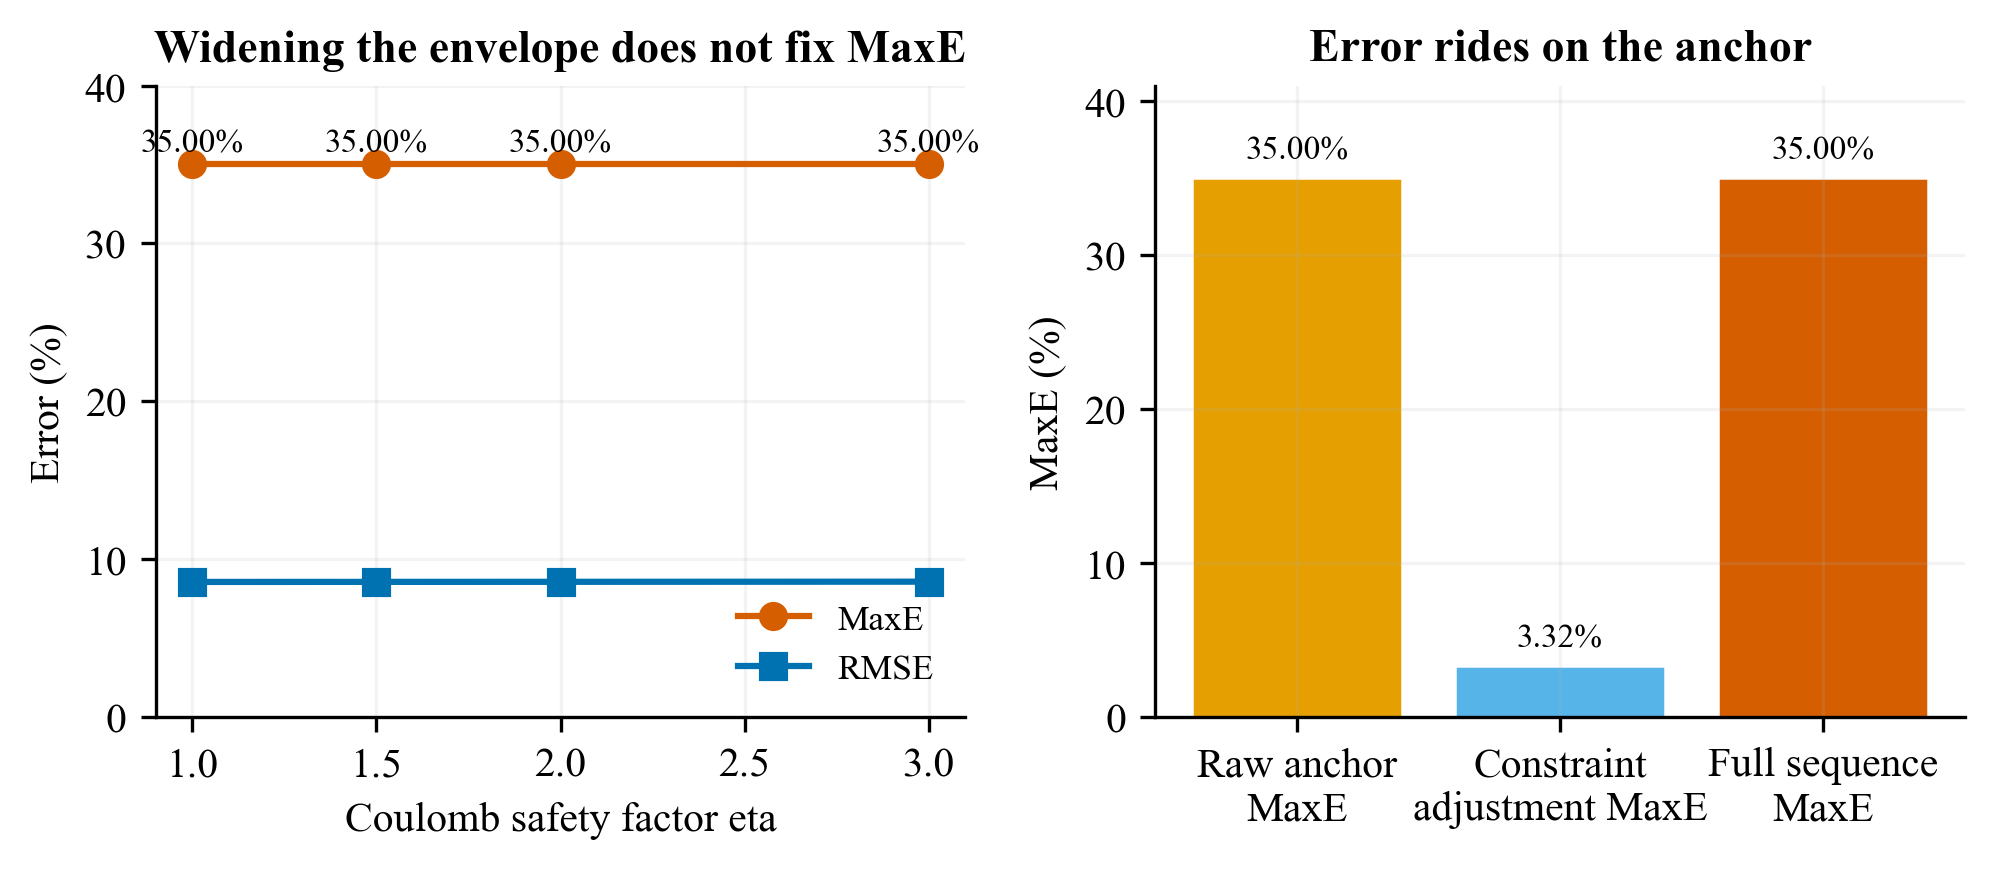

Saved: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies\fig_08_anchor_trap_eta_non_cause.pdf
Saved: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies\fig_08_anchor_trap_eta_non_cause.png


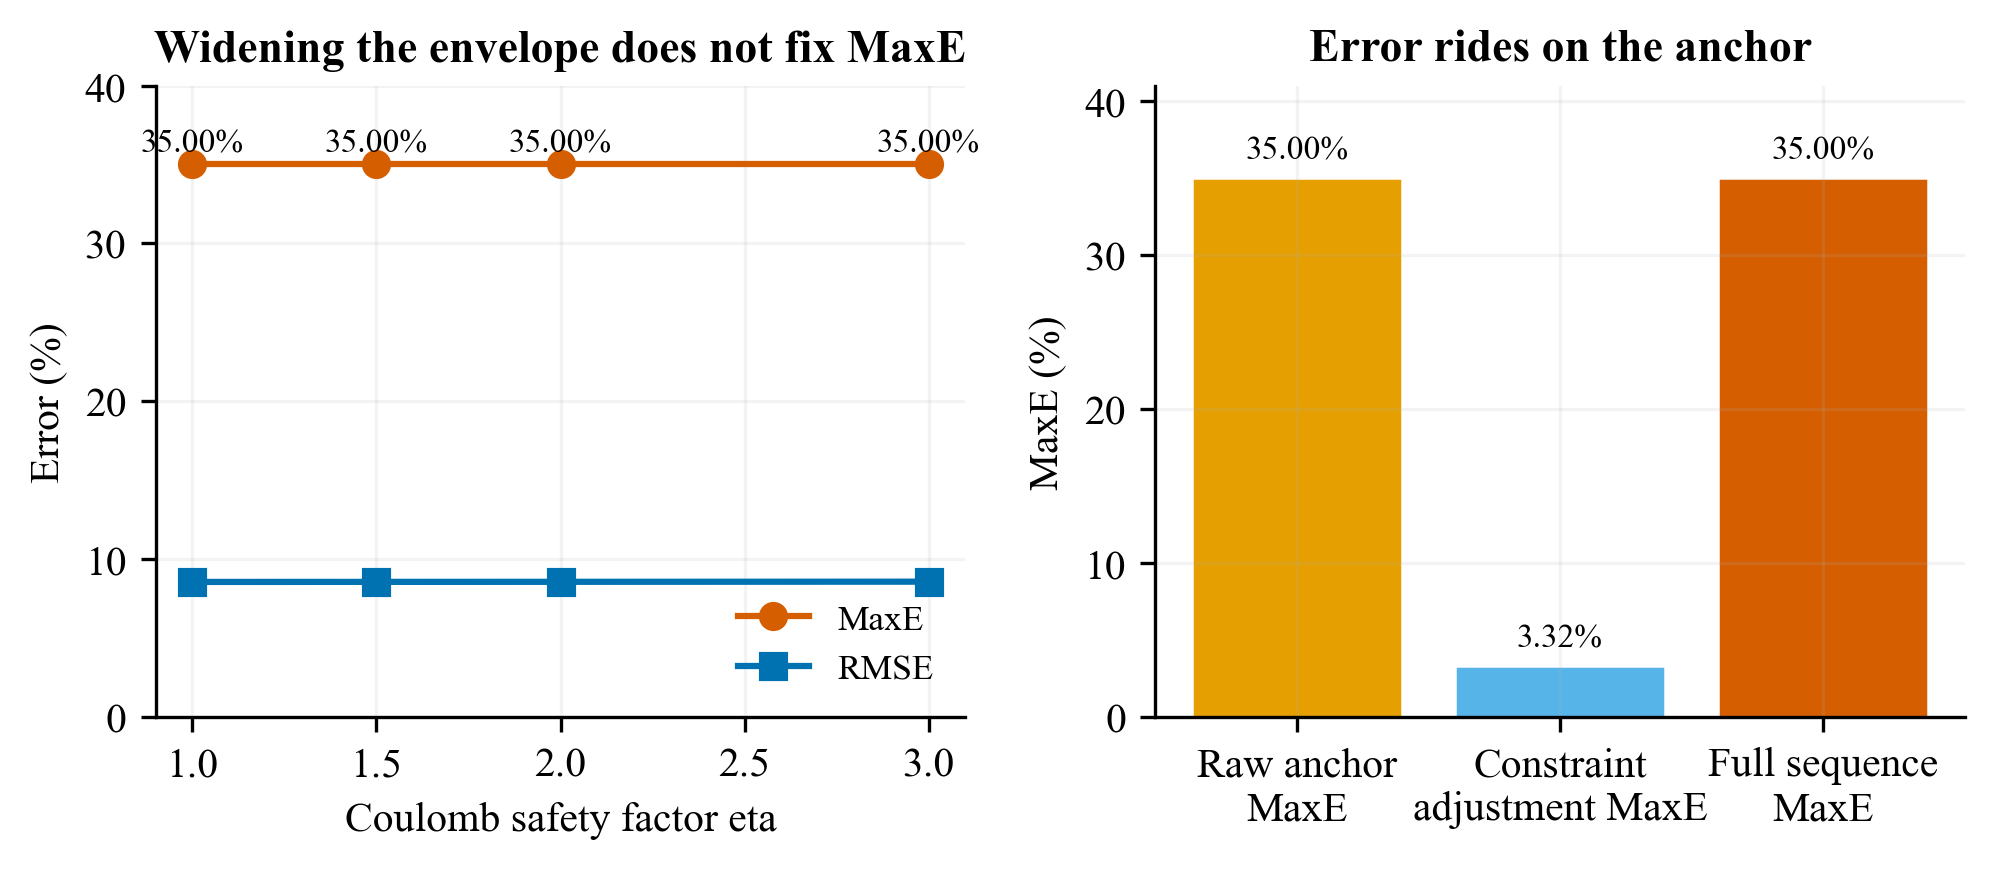

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(6.75, 3.0))

ax = axes[0]
ax.plot(eta_df['Eta'], eta_df['MaxE (%)'], marker='o', color='#D55E00', label='MaxE')
ax.plot(eta_df['Eta'], eta_df['RMSE (%)'], marker='s', color='#0072B2', label='RMSE')
for _, row in eta_df.iterrows():
    ax.text(row['Eta'], row['MaxE (%)'] + 0.35, f"{row['MaxE (%)']:.2f}%", ha='center', va='bottom', fontsize=8)
ax.set_xlabel('Coulomb safety factor eta')
ax.set_ylabel('Error (%)')
ax.set_title('Widening the envelope does not fix MaxE')
ax.set_ylim(0, max(40.0, eta_df['MaxE (%)'].max() + 4.0))
ax.legend(loc='lower right')

ax = axes[1]
scenario_b = anchor_df[anchor_df['Scenario'] == 'Scenario B'].iloc[0]
labels = ['Raw anchor\nMaxE', 'Constraint\nadjustment MaxE', 'Full sequence\nMaxE']
values = [scenario_b['Raw anchor MaxE (%)'], scenario_b['Constraint adjustment MaxE (%)'], scenario_b['Full MaxE (%)']]
colors = ['#E69F00', '#56B4E9', '#D55E00']
bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=0.6)
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.8, f'{value:.2f}%', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('MaxE (%)')
ax.set_title('Error rides on the anchor')
ax.set_ylim(0, max(values) + 6.0)
fig.tight_layout()
pdf_path = FIG_DIR / 'fig_08_anchor_trap_eta_non_cause.pdf'
png_path = FIG_DIR / 'fig_08_anchor_trap_eta_non_cause.png'
fig.savefig(pdf_path)
fig.savefig(png_path, dpi=300)
display(fig)
print(f'Saved: {pdf_path}')
print(f'Saved: {png_path}')


## Autopsy

The eta sweep proves the high cold-error tail is not caused by an overly restrictive Coulomb envelope. Scenario B MaxE remains `34.9985%` for eta `1.0`, `1.5`, `2.0`, and `3.0`. The constraint preserves safety direction; the missing information is absolute initial SOC under weak voltage observability.
